In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_excel('Data_Train.xlsx')

In [5]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [7]:
df.shape

(10683, 11)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [11]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [13]:
df.isnull().sum()/df.shape[0]*100

Airline            0.000000
Date_of_Journey    0.000000
Source             0.000000
Destination        0.000000
Route              0.009361
Dep_Time           0.000000
Arrival_Time       0.000000
Duration           0.000000
Total_Stops        0.009361
Additional_Info    0.000000
Price              0.000000
dtype: float64

In [15]:
df['Route'].mode()

0    DEL → BOM → COK
Name: Route, dtype: object

In [17]:
df['Route']=df['Route'].fillna(df['Route'].mode()[0])

In [19]:
df['Total_Stops'].mode()

0    1 stop
Name: Total_Stops, dtype: object

In [21]:
df['Total_Stops']=df['Total_Stops'].fillna(df['Total_Stops'].mode()[0])

In [23]:
df.isnull().sum()/df.shape[0]*100

Airline            0.0
Date_of_Journey    0.0
Source             0.0
Destination        0.0
Route              0.0
Dep_Time           0.0
Arrival_Time       0.0
Duration           0.0
Total_Stops        0.0
Additional_Info    0.0
Price              0.0
dtype: float64

In [25]:
df['Date_of_Journey']=pd.to_datetime(df['Date_of_Journey'])

In [27]:
df.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Airline          10683 non-null  object        
 1   Date_of_Journey  10683 non-null  datetime64[ns]
 2   Source           10683 non-null  object        
 3   Destination      10683 non-null  object        
 4   Route            10683 non-null  object        
 5   Dep_Time         10683 non-null  object        
 6   Arrival_Time     10683 non-null  object        
 7   Duration         10683 non-null  object        
 8   Total_Stops      10683 non-null  object        
 9   Additional_Info  10683 non-null  object        
 10  Price            10683 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(9)
memory usage: 918.2+ KB


In [31]:
df['Total_Stops'].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', '4 stops'],
      dtype=object)

In [33]:
df.replace({'non-stop':0, '2 stops':1, '1 stop':2, '3 stops':3, '4 stops':4},inplace=True)

In [35]:
df.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,0,No info,3897
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,1,No info,7662
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,1,No info,13882


# HOW MANY FLIGHTS WITH RESPECT TO THEIR STOPAGES

In [38]:
df['Total_Stops'].value_counts()

Total_Stops
2    5626
0    3491
1    1520
3      45
4       1
Name: count, dtype: int64

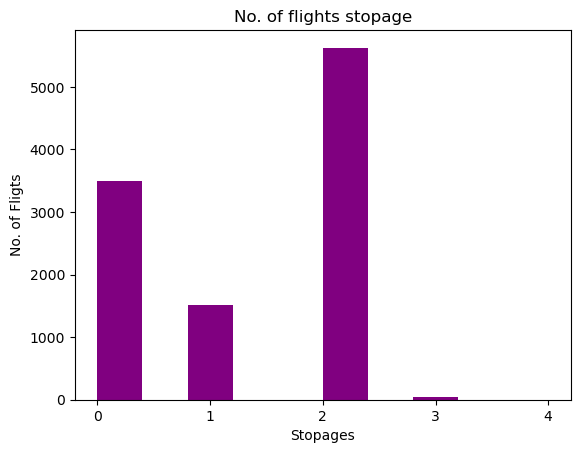

In [40]:
plt.title('No. of flights stopage')
plt.hist(df['Total_Stops'],color='purple')
plt.xlabel('Stopages')
plt.ylabel('No. of Fligts')
plt.xticks(df['Total_Stops'].unique());

# WHICH AIRLINE has most stopages

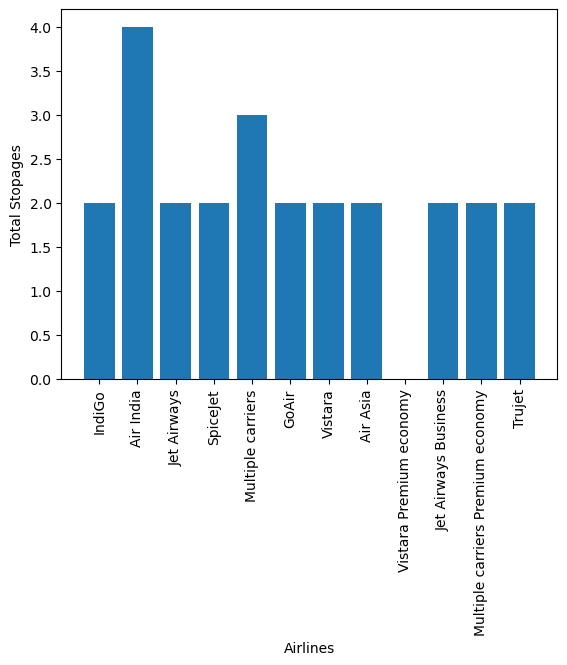

In [43]:
plt.bar(df['Airline'],df['Total_Stops'])
plt.xlabel('Airlines')
plt.ylabel('Total Stopages')
plt.xticks(rotation=90);

# WHAT FLIGHT IS EXPENSIVE & CHEAPER

In [46]:
p=df.groupby(['Airline'])['Price'].agg(['min','max']).reset_index().sort_values(by='max',ascending=False)

In [48]:
p

,Airline,min,max
5,Jet Airways Business,46490,79512
4,Jet Airways,1840,54826
6,Multiple carriers,5797,36983
1,Air India,2050,31945
8,SpiceJet,1759,23267
2,GoAir,3398,22794
3,IndiGo,2227,22153
10,Vistara,3687,21730
7,Multiple carriers Premium economy,9845,14629
0,Air Asia,3383,13774


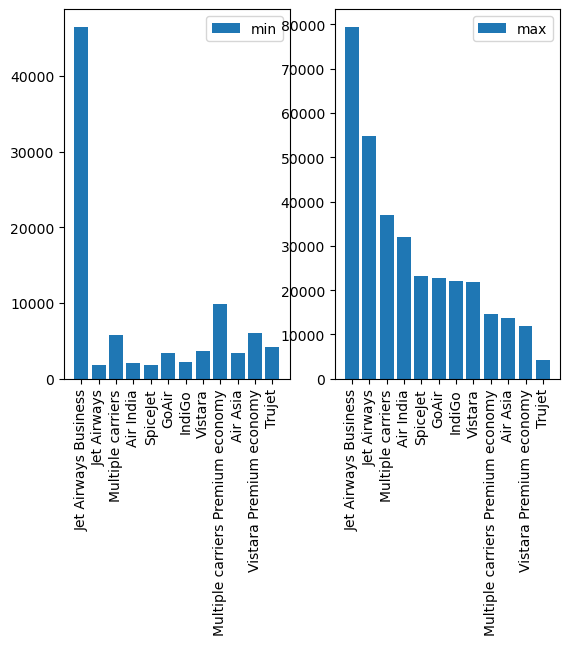

In [50]:
plt.subplot(1,2,1)
plt.bar(p['Airline'],p['min'],label='min')
plt.xticks(rotation=90)
plt.legend();
plt.subplot(1,2,2)
plt.bar(p['Airline'],p['max'],label='max')
plt.xticks(rotation=90)
plt.legend();

# VARIATION OF FLIGHT PRICE FROM SOURCE

In [53]:
df['Destination'].unique()

array(['New Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Delhi', 'Hyderabad'],
      dtype=object)

In [55]:
df.replace({'New Delhi':'Delhi'},inplace=True)

In [57]:
sd=df.groupby(['Source','Destination'])['Price'].agg(['sum','max','min','mean']).reset_index()

In [59]:
sd

,Source,Destination,sum,max,min,mean
0,Banglore,Delhi,17614369,79512,3257,8017.464269
1,Chennai,Kolkata,1824949,19630,3145,4789.892388
2,Delhi,Cochin,47817435,52285,3876,10539.439057
3,Kolkata,Banglore,26293736,31945,3480,9158.389411
4,Mumbai,Hyderabad,3526617,25139,1759,5059.708752


In [61]:
sd=df.groupby(['Source','Destination','Airline'])['Price'].agg(['sum','max','min','mean']).reset_index()

In [63]:
sd

,Source,Destination,Airline,sum,max,min,mean
0,Banglore,Delhi,Air Asia,407111,10873,3383,4574.280899
1,Banglore,Delhi,Air India,3067082,31783,3758,9238.198795
2,Banglore,Delhi,GoAir,460246,18558,3398,4948.881720
3,Banglore,Delhi,IndiGo,2758361,22153,3359,5274.112811
4,Banglore,Delhi,Jet Airways,8685125,54826,3359,11021.732234
5,Banglore,Delhi,Jet Airways Business,251377,79512,52229,62844.250000
6,Banglore,Delhi,SpiceJet,823603,23267,3257,4550.292818
7,Banglore,Delhi,Vistara,1143702,21730,4353,6182.172973
8,Banglore,Delhi,Vistara Premium economy,17762,11793,5969,8881.000000
9,Chennai,Kolkata,Air India,147391,19630,3145,5895.640000


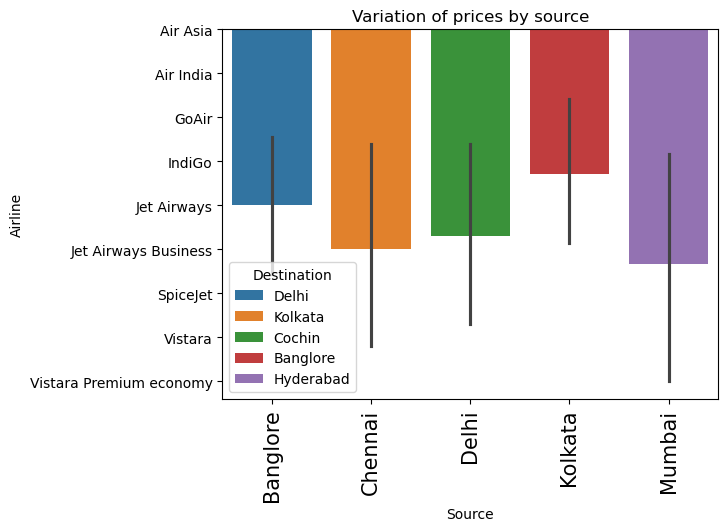

In [65]:
sns.barplot(x='Source',y='Airline',hue='Destination',data=sd)
plt.xticks(rotation=90,size=15)
plt.title('Variation of prices by source')
plt.show()

In [67]:
df.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,2019-03-24,Banglore,Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,0,No info,3897
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,1,No info,7662


In [69]:
df['Date_of_Journey'].unique()

<DatetimeArray>
['2019-03-24 00:00:00', '2019-05-01 00:00:00', '2019-06-09 00:00:00',
 '2019-05-12 00:00:00', '2019-03-01 00:00:00', '2019-06-24 00:00:00',
 '2019-03-12 00:00:00', '2019-05-27 00:00:00', '2019-06-01 00:00:00',
 '2019-04-18 00:00:00', '2019-05-09 00:00:00', '2019-04-24 00:00:00',
 '2019-03-03 00:00:00', '2019-04-15 00:00:00', '2019-06-12 00:00:00',
 '2019-03-06 00:00:00', '2019-03-21 00:00:00', '2019-04-03 00:00:00',
 '2019-05-06 00:00:00', '2019-05-15 00:00:00', '2019-06-18 00:00:00',
 '2019-06-15 00:00:00', '2019-04-06 00:00:00', '2019-05-18 00:00:00',
 '2019-06-27 00:00:00', '2019-05-21 00:00:00', '2019-06-03 00:00:00',
 '2019-03-15 00:00:00', '2019-05-03 00:00:00', '2019-03-09 00:00:00',
 '2019-06-06 00:00:00', '2019-05-24 00:00:00', '2019-04-01 00:00:00',
 '2019-04-21 00:00:00', '2019-06-21 00:00:00', '2019-03-27 00:00:00',
 '2019-03-18 00:00:00', '2019-04-12 00:00:00', '2019-04-09 00:00:00',
 '2019-04-27 00:00:00']
Length: 40, dtype: datetime64[ns]

In [71]:
df['Day_of_Journey']=df['Date_of_Journey'].dt.day

In [73]:
df['Month_of_Journey']=df['Date_of_Journey'].dt.month

In [75]:
df.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey
0,IndiGo,2019-03-24,Banglore,Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,0,No info,3897,24,3
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,1,No info,7662,1,5


In [77]:
df['Day_of_Journey'].unique()

array([24,  1,  9, 12, 27, 18,  3, 15,  6, 21])

In [79]:
df['Month_of_Journey'].unique()

array([3, 5, 6, 4])

In [81]:
df.drop(columns='Date_of_Journey',inplace=True)

# ON WHAT MONTH HAVE MAX FLIGHTS TAKE OFF

In [84]:
df['Month_of_Journey'].value_counts()

Month_of_Journey
5    3466
6    3414
3    2724
4    1079
Name: count, dtype: int64

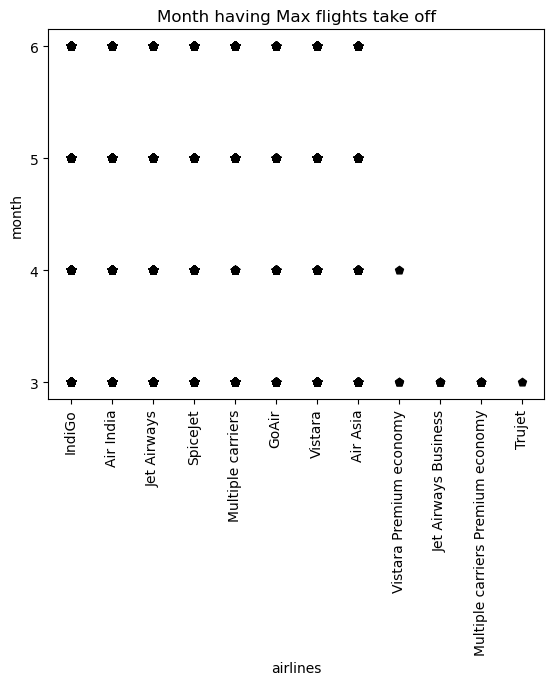

In [86]:
month=list(df['Month_of_Journey'])
airline=list(df['Airline'])
plt.scatter(airline,month,marker='p',color='k')
plt.xticks(rotation=90)
plt.yticks(df['Month_of_Journey'].unique())
plt.title('Month having Max flights take off')
plt.xlabel('airlines')
plt.ylabel('month');

# WHAT MONTH HAS MAX EARNING

In [89]:
p=df.groupby(['Month_of_Journey'])['Price'].agg(['sum']).reset_index().sort_values(by='sum',ascending=False)

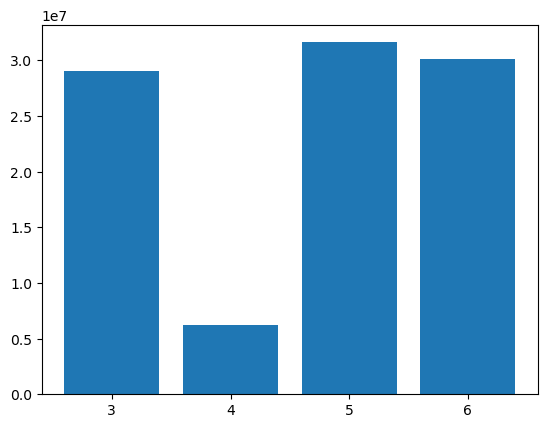

In [91]:
plt.bar(p['Month_of_Journey'],p['sum'])
plt.xticks(p['Month_of_Journey']);

# AVAILABILITY OF FLIGHT WITH RESPECT TO SOURCE & DESTINATION

In [94]:
df1=df.groupby(['Destination','Source'])['Airline'].value_counts()

In [96]:
df1

Destination  Source    Airline                          
Banglore     Kolkata   Jet Airways                          1256
                       Air India                             512
                       IndiGo                                445
                       SpiceJet                              300
                       Vistara                               183
                       Air Asia                              150
                       GoAir                                  25
Cochin       Delhi     Jet Airways                          1586
                       Multiple carriers                    1196
                       Air India                             747
                       IndiGo                                705
                       SpiceJet                               87
                       Air Asia                               80
                       GoAir                                  76
                       Vistara   